<a href="https://colab.research.google.com/github/Vykhrystenko/ML_FIT_3-9_Vykhrystenko/blob/main/%D0%9B%D0%A0_2_2_%D0%92%D0%B8%D1%85%D1%80%D0%B8%D1%81%D1%82%D0%B5%D0%BD%D0%BA%D0%BE_3_9.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [1]:
import numpy as np
import pandas as pd
import seaborn as sns
import matplotlib.pyplot as plt

In [2]:
import kagglehub
import os

path = kagglehub.dataset_download("mahmoudshogaa/titanic-dataset")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'titanic-dataset' dataset.
Path to dataset files: /kaggle/input/titanic-dataset


In [3]:
df = pd.read_csv(os.path.join(path, "titanic.csv"))

df

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S
...,...,...,...,...,...,...,...,...,...,...,...,...
886,887,0,2,"Montvila, Rev. Juozas",male,27.0,0,0,211536,13.0000,NaN,S
887,888,1,1,"Graham, Miss. Margaret Edith",female,19.0,0,0,112053,30.0000,B42,S
888,889,0,3,"Johnston, Miss. Catherine Helen ""Carrie""",female,NaN,1,2,W./C. 6607,23.4500,NaN,S
889,890,1,1,"Behr, Mr. Karl Howell",male,26.0,0,0,111369,30.0000,C148,C


Набір даних зазвичай містить такі стовпці:

**PassengerId**: унікальний ідентифікатор для кожного пасажира.

**Survived**: Цей стовпець показує, чи вижив пасажир (1) чи не вижив (0).

**Pclass** (клас квитків): Проксі соціально-економічного статусу, де 1 — найвищий клас, а 3 — найнижчий.

**Name**: ім'я пасажира.

**Sex**: стать пасажира.

**Age**: Вік пасажира. (Примітка: у цьому стовпці можуть бути відсутні значення.)

**SibSp**: Кількість братів, сестер або подружжя пасажира на борту Титаніка.

**Parch**: Кількість батьків або дітей, яких пасажир мав на борту Титаніка.

**Ticket**: Номер квитка.

**Fare**: Сума, яку пасажир заплатив за квиток.

Головна мета використання цього набору даних — передбачити, чи вижив пасажир, на основі різних ознак. Він слугує популярним вступним набором даних для тих, хто навчається аналізу даних, машинному навчанню та прогнозованому моделюванню. Майте на увазі, що набір даних може зазнавати варіацій і оновлень, тому завжди корисно перевіряти сайт Kaggle або документацію набору даних для найсвіжішої інформації.

2-3.Визначення розміру та типу даних датасету

In [4]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


4.Перевірка на наявність пропущених значень. Заміна їх на медіану

In [5]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,177
SibSp,0
Parch,0
Ticket,0
Fare,0


In [6]:
df['Age'] = df['Age'].fillna(df['Age'].median(skipna=True))

df.drop(['Cabin'], axis=1, inplace=True) # вирішили видалити колонку
df.drop(['Embarked'], axis=1, inplace=True)

5. Перевірка на наявність пропущених значень

In [7]:
df.isnull().sum()

,0
PassengerId,0
Survived,0
Pclass,0
Name,0
Sex,0
Age,0
SibSp,0
Parch,0
Ticket,0
Fare,0


6. Формування датасету з наступними стовбцями: ("Survived","Pclass","Sex","Age","Fare")

In [8]:
df = df[['Survived', 'Pclass', 'Sex', 'Age', 'Fare']]

df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,male,22.0,7.2500
1,1,1,female,38.0,71.2833
2,1,3,female,26.0,7.9250
3,1,1,female,35.0,53.1000
4,0,3,male,35.0,8.0500


7. Замінив бінарні ознаки на 0 та 1

In [9]:
df['Sex'].value_counts()

,count
Sex,
male,577
female,314


In [10]:
df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})

print(f'Data types of the dataset:\n{df.dtypes}')

Data types of the dataset:
Survived      int64
Pclass        int64
Sex           int64
Age         float64
Fare        float64
dtype: object


/tmp/ipykernel_1152/275882515.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Sex'] = df['Sex'].map({'male': 0, 'female': 1})


8.

In [11]:
df.describe()

,Survived,Pclass,Sex,Age,Fare
count,891.000000,891.000000,891.000000,891.000000,891.000000
mean,0.383838,2.308642,0.352413,29.361582,32.204208
std,0.486592,0.836071,0.477990,13.019697,49.693429
min,0.000000,1.000000,0.000000,0.420000,0.000000
25%,0.000000,2.000000,0.000000,22.000000,7.910400
50%,0.000000,3.000000,0.000000,28.000000,14.454200
75%,1.000000,3.000000,1.000000,35.000000,31.000000
max,1.000000,3.000000,1.000000,80.000000,512.329200


9.Ще раз перевірити кількість пропущених даних (впевнитись, що їх немає).

In [12]:
df.isnull().sum()

,0
Survived,0
Pclass,0
Sex,0
Age,0
Fare,0


10.Вивести 5 перших рядків датасету.

In [13]:
df.head()

,Survived,Pclass,Sex,Age,Fare
0,0,3,0,22.0,7.2500
1,1,1,1,38.0,71.2833
2,1,3,1,26.0,7.9250
3,1,1,1,35.0,53.1000
4,0,3,0,35.0,8.0500


11.Вивести 5 останніх рядків датасету.

In [14]:
df.tail()

,Survived,Pclass,Sex,Age,Fare
886,0,2,0,27.0,13.00
887,1,1,1,19.0,30.00
888,0,3,1,28.0,23.45
889,1,1,0,26.0,30.00
890,0,3,0,32.0,7.75


12.Аналіз виживання залежно від статі: Обчисліть відсоток виживання для кожної статі. Чи була різниця у виживанні між чоловіками та жінками?

In [15]:
survival_by_sex = df.groupby('Sex')['Survived'].mean() * 100

print(f'Share of survived males: {survival_by_sex[0]:.2f}%')
print(f'Share of survived females: {survival_by_sex[1]:.2f}%')

Share of survived males: 18.89%
Share of survived females: 74.20%


In [16]:
print(f'Correlation between sex and survival: {df["Sex"].corr(df["Survived"])}')

Correlation between sex and survival: 0.5433513806577555


Відсоток виживання жінок є значно більшим

13.Обчисліть відсоток виживання для кожного класу (Pclass). Який клас мав найвищий рівень виживання (дати відповідь)?

In [17]:
class1_surv_rate = df[(df['Pclass'] == 1) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 1].shape[0]
class2_surv_rate = df[(df['Pclass'] == 2) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 2].shape[0]
class3_surv_rate = df[(df['Pclass'] == 3) & (df['Survived'] == 1)].shape[0] / df[df['Pclass'] == 3].shape[0]

print(f'Share of survived class 1 passengers {class1_surv_rate * 100:.2f}%')
print(f'Share of survived class 2 passengers {class2_surv_rate * 100:.2f}%')
print(f'Share of survived class 3 passengers {class3_surv_rate * 100:.2f}%')

Share of survived class 1 passengers 62.96%
Share of survived class 2 passengers 47.28%
Share of survived class 3 passengers 24.24%


1 клас має найвищий відсоток виживання

14.Визначте середній вік тих, хто вижив, і тих, хто не вижив. Чи впливає вік на виживання (дати відповідь)?

In [18]:
survived_mean_age = df[df['Survived'] == 1]['Age'].mean()
not_survived_mean_age = df[df['Survived'] == 0]['Age'].mean()

print(f'Mean age of survived passengers: {survived_mean_age:.2f}')
print(f'Mean age of not survived passengers: {not_survived_mean_age:.2f}')

Mean age of survived passengers: 28.29
Mean age of not survived passengers: 30.03


Вік не впливає на шанс виживання

15.Розподіліть пасажирів на групи за рівнями тарифів (Fare) і обчисліть рівень виживання для кожної групи. Як тариф впливав на шанси виживання (дати відповідь)?

In [19]:
df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)

for i in range(6):
    surv_rate = df[(df['Fare_Category'] == i) & (df['Survived'] == 1)].shape[0] / df[df['Fare_Category'] == i].shape[0]
    print(f'Share of survived passengers in bucket {i}: {surv_rate * 100:.2f}%')

Share of survived passengers in bucket 0: 20.51%
Share of survived passengers in bucket 1: 19.08%
Share of survived passengers in bucket 2: 36.69%
Share of survived passengers in bucket 3: 43.62%
Share of survived passengers in bucket 4: 41.78%
Share of survived passengers in bucket 5: 69.80%


/tmp/ipykernel_1152/1421978565.py:1: SettingWithCopyWarning: 
A value is trying to be set on a copy of a slice from a DataFrame.
Try using .loc[row_indexer,col_indexer] = value instead

See the caveats in the documentation: https://pandas.pydata.org/pandas-docs/stable/user_guide/indexing.html#returning-a-view-versus-a-copy
  df['Fare_Category'] = pd.qcut(df['Fare'], 6, labels=False)


Бачимо, що пасажири з дорожчими квитками мали вищий шанс на виживання

16.Аналіз класу та тарифу: Визначте середній тариф (Fare) для кожного класу (Pclass). Чи існує значна різниця у тарифах між класами (дати відповідь)?

In [20]:
for i in range(1, 4):
    median_fare = df[df['Pclass'] == i]['Fare'].median()
    print(f'Median fare for class {i}: {median_fare:.2f}')

Median fare for class 1: 60.29
Median fare for class 2: 14.25
Median fare for class 3: 8.05


Ціна за квитки першого класу дорожчі у 4 рази за квитки другого класу, та у 7,5 раз за квитки третього класу

17.Як пов'язано середній вік пасажирів з виживанням?Відповідь дати аналітично чи графічно

<Axes: xlabel='Age', ylabel='Count'>

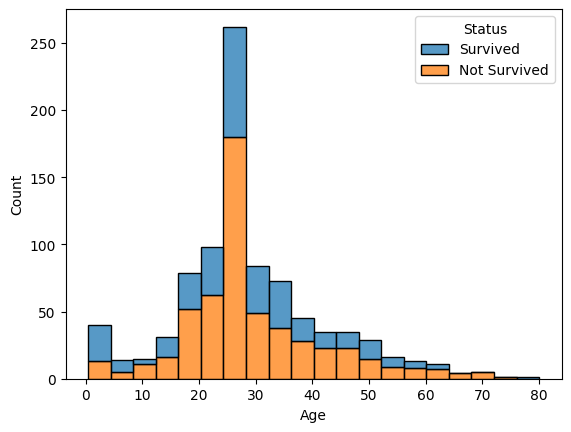

In [21]:
df_survived = df[df['Survived'] == 1][['Age']]
df_survived['Status'] = 'Survived'

df_not_survived = df[df['Survived'] == 0][['Age']]
df_not_survived['Status'] = 'Not Survived'

df_combined = pd.concat([df_survived, df_not_survived])

sns.histplot(data=df_combined, x='Age', hue='Status', bins=20, multiple='stack')

Середній вік пасажирів, які вижили, є дещо нижчим порівняно з тими, хто загинув (приблизно 28 років проти 30 років). Основною причиною такої різниці є пріоритетна евакуація дітей, частка виживання серед яких була найвищою.Найбільшою групою загиблих була молодь віком 20–30 років, що також знизило загальний середній вік тих, хто вижив

In [22]:
for i in range(1, 4):
    for j in range(2):
        surv_rate = df[(df['Pclass'] == i) & (df['Sex'] == j) & (df['Survived'] == 1)].shape[0] / df[(df['Pclass'] == i) & (df['Sex'] == j)].shape[0]
        print(f'Share of survived {"male " if j == 0 else "female"} passengers in class {i}: {surv_rate * 100:.2f}%')

Share of survived male  passengers in class 1: 36.89%
Share of survived female passengers in class 1: 96.81%
Share of survived male  passengers in class 2: 15.74%
Share of survived female passengers in class 2: 92.11%
Share of survived male  passengers in class 3: 13.54%
Share of survived female passengers in class 3: 50.00%


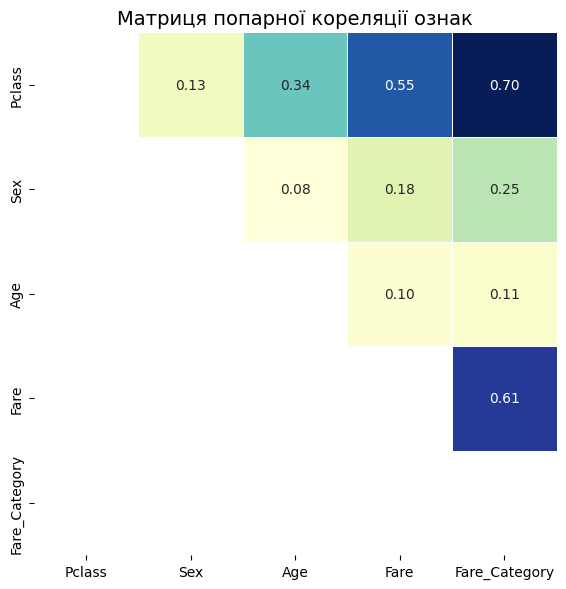

In [23]:
mtx = df.drop('Survived', axis=1).corr(numeric_only=True).abs()

fig, ax = plt.subplots(figsize=(6, 6))

sns.heatmap(
    mtx,
    cmap='YlGnBu',
    annot=True,
    fmt=".2f",
    linewidths=0.5,
    mask=np.tril(np.ones_like(mtx, dtype=bool)),
    square=True,
    cbar=False,
    ax=ax
)

plt.title("Матриця попарної кореляції ознак", fontsize=14)
plt.tight_layout()
plt.show()

Завдання 2

In [41]:
from google.colab import drive
import pandas as pd

drive.mount("/content/drive")
file_path = '/content/drive/MyDrive/bestsellers.csv'

Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).


In [ ]:
df = pd.read_csv(file_path)
df.head()

In [46]:
import kagglehub

path = kagglehub.dataset_download("sootersaalu/amazon-top-50-bestselling-books-2009-2019")

print("Path to dataset files:", path)

Using Colab cache for faster access to the 'amazon-top-50-bestselling-books-2009-2019' dataset.
Path to dataset files: /kaggle/input/amazon-top-50-bestselling-books-2009-2019


In [47]:
df = pd.read_csv(os.path.join(path, "bestsellers with categories.csv"))
df

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction
...,...,...,...,...,...,...,...
545,Wrecking Ball (Diary of a Wimpy Kid Book 14),Jeff Kinney,4.9,9413,8,2019,Fiction
546,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2016,Non Fiction
547,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2017,Non Fiction
548,You Are a Badass: How to Stop Doubting Your Gr...,Jen Sincero,4.7,14331,8,2018,Non Fiction


In [48]:
df.head()

,Name,Author,User Rating,Reviews,Price,Year,Genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [49]:
df.shape

(550, 7)

In [50]:
df.duplicated().sum()

np.int64(0)

In [51]:
df.duplicated(subset='Name').sum()

np.int64(199)

In [52]:
df = df.drop_duplicates(subset='Name')

In [53]:
df.shape

(351, 7)

In [54]:
df.columns = ['name', 'author', 'user_rating', 'reviews', 'price', 'year', 'genre']
df.head()

,name,author,user_rating,reviews,price,year,genre
0,10-Day Green Smoothie Cleanse,JJ Smith,4.7,17350,8,2016,Non Fiction
1,11/22/63: A Novel,Stephen King,4.6,2052,22,2011,Fiction
2,12 Rules for Life: An Antidote to Chaos,Jordan B. Peterson,4.7,18979,15,2018,Non Fiction
3,1984 (Signet Classics),George Orwell,4.7,21424,6,2017,Fiction
4,"5,000 Awesome Facts (About Everything!) (Natio...",National Geographic Kids,4.8,7665,12,2019,Non Fiction


In [55]:
df.info()

<class 'pandas.core.frame.DataFrame'>
Index: 351 entries, 0 to 546
Data columns (total 7 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   name         351 non-null    object 
 1   author       351 non-null    object 
 2   user_rating  351 non-null    float64
 3   reviews      351 non-null    int64  
 4   price        351 non-null    int64  
 5   year         351 non-null    int64  
 6   genre        351 non-null    object 
dtypes: float64(1), int64(3), object(3)
memory usage: 21.9+ KB


In [56]:
df['genre'].unique()

array(['Non Fiction', 'Fiction'], dtype=object)

Non Fiction, Fiction є унікальними жанрами

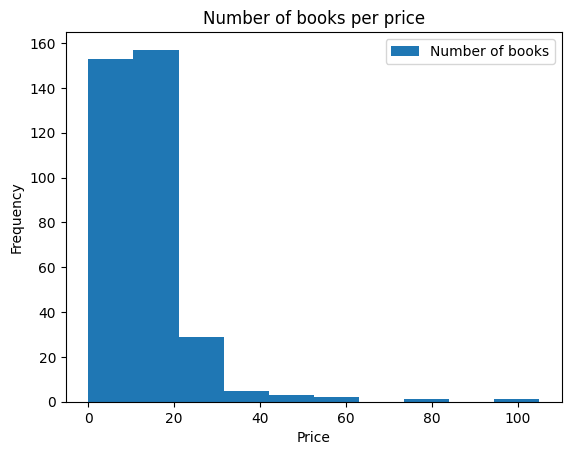

In [60]:
df['price'].plot(kind='hist', label='Number of books')
plt.xlabel('Price')
plt.title('Number of books per price')
plt.legend()
plt.show()

In [62]:
max_price = df['price'].max()
min_price = df['price'].min()
mean_price = df['price'].mean()
median_price = df['price'].median()

print(f'Максимальна ціна: {max_price}')
print(f'Мінімальна ціна: {min_price}')
print(f'Середня ціна: {mean_price:.2f}')
print(f'Медіанна ціна: {median_price}')

Максимальна ціна: 105
Мінімальна ціна: 0
Середня ціна: 13.08
Медіанна ціна: 12.0


In [65]:
max_rating = df['user_rating'].max()
print(f'Найвищий рейтинг у датасеті: {max_rating}')

Найвищий рейтинг у датасеті: 4.9


In [68]:
count_books = (df['user_rating'] == max_rating).sum()
print(f'Кількість книг з найвищим рейтингом ({max_rating}): {count_books}')

Кількість книг з найвищим рейтингом (4.9): 28


In [70]:
max_reviews_book = df.loc[df['reviews'].idxmax()]
print(
    f"Книга з найбільшою кількістю відгуків: {max_reviews_book['name']} ("
    f"{max_reviews_book['reviews']} відгуків)"
)

Книга з найбільшою кількістю відгуків: Where the Crawdads Sing (87841 відгуків)


In [72]:
df_2015 = df[df['year'] == 2015]
max_price_book_2015 = df_2015.loc[df_2015['price'].idxmax()]

print(
    f"Найдорожча книга 2015 року: {max_price_book_2015['name']} "
    f"({max_price_book_2015['author']}) — {max_price_book_2015['price']} $"
)

Найдорожча книга 2015 року: Go Set a Watchman: A Novel (Harper Lee) — 19 $


In [73]:
fiction_2010_count = (
    (df['year'] == 2010) & (df['genre'] == 'fiction')
).sum()
print(
    f'Кількість книг жанру Fiction у 2010 році: {fiction_2010_count}'
)

Кількість книг жанру Fiction у 2010 році: 0


In [75]:
count_books = (
    (df['user_rating'] == 4.9)
    & ((df['year'] == 2010) | (df['year'] == 2011))
).sum()
print(
    f'Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: {count_books}'
)

Кількість книг з рейтингом 4.9 у 2010 та 2011 роках: 1


In [77]:
filtered_df = df[(df['year'] == 2015) & (df['price'] < 8)].sort_values(
    by='price', ascending=True
)

display(filtered_df)

last_book = filtered_df.iloc[-1]
print(
    f"Остання книга у відсортованому списку: {last_book['name']} "
    f"({last_book['price']} $)"
)

,name,author,user_rating,reviews,price,year,genre
54,Creative Haven Creative Cats Coloring Book (Ad...,Marjorie Sarnat,4.8,4022,4,2015,Non Fiction
123,Giraffes Can't Dance,Giles Andreae,4.8,14038,4,2015,Fiction
55,Creative Haven Owls Coloring Book (Adult Color...,Marjorie Sarnat,4.8,3871,5,2015,Non Fiction
28,Baby Touch and Feel: Animals,DK,4.6,5360,5,2015,Non Fiction
63,Dear Zoo: A Lift-the-Flap Book,Rod Campbell,4.8,10922,5,2015,Fiction
89,Dover Creative Haven Art Nouveau Animal Design...,Marty Noble,4.6,2134,5,2015,Non Fiction
201,Killing Reagan: The Violent Assault That Chang...,Bill O'Reilly,4.6,5235,5,2015,Non Fiction
16,Adult Coloring Book: Stress Relieving Animal D...,Blue Star Coloring,4.6,2925,6,2015,Non Fiction
17,Adult Coloring Book: Stress Relieving Patterns,Blue Star Coloring,4.4,2951,6,2015,Non Fiction
253,Old School (Diary of a Wimpy Kid #10),Jeff Kinney,4.8,6169,7,2015,Fiction


Остання книга у відсортованому списку: Old School (Diary of a Wimpy Kid #10) (7 $)


In [79]:
result = df[['genre', 'price']].groupby('genre').agg({'price': ['min', 'max']})
print(result)

            price     
              min  max
genre                 
Fiction         0   82
Non Fiction     0  105
